# 🤖 E-Commerce Customer Segmentation - Machine Learning Implementation

**Objective:** Apply K-Means clustering algorithm to segment 6,000 e-commerce customers using RFM analysis, evaluate model performance, and compare ML-based segmentation with rule-based RFM approach.

**Dataset:** ~67,700 synthetic transactions across 5 product categories (2022-2024)

**Key Techniques:** 
- Machine Learning: K-Means Clustering (scikit-learn)
- Feature Scaling: StandardScaler
- Model Evaluation: Silhouette Score, Davies-Bouldin Index, Calinski-Harabasz Score
- Hyperparameter Tuning: Elbow Method (K=2 to 12)

**Expected Outcome:** Trained ML model saved as .pkl files, cluster visualizations, and comparison with RFM segments.

# 1. Setup & Imports

In [21]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Machine Learning imports
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import joblib
import json

# Visualization settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Create required folders
os.makedirs('models', exist_ok=True)
os.makedirs('outputs', exist_ok=True)
os.makedirs('outputs/ml_results', exist_ok=True)

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


## 2. Data Loading & Exploration

We start by loading the transaction dataset and getting an overview of its structure, shape, and basic statistics.

In [22]:
# Load transaction data
df = pd.read_csv('../data/ecommerce_transactions.csv')
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

print("=" * 70)
print("DATASET OVERVIEW")
print("=" * 70)
print(f"\nShape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nData Types:\n{df.dtypes}")
print(f"\nBasic Statistics:\n{df.describe()}")

DATASET OVERVIEW

Shape: 67,731 rows × 5 columns

First 5 rows:
  transaction_id customer_id transaction_date       category  amount
0     TXN_064605  CUST_05726       2022-11-02       Clothing  124.11
1     TXN_050656  CUST_04505       2023-02-10       Clothing  162.98
2     TXN_025685  CUST_02304       2023-07-16  Home & Garden   50.60
3     TXN_012352  CUST_01094       2023-10-26    Electronics   46.60
4     TXN_026714  CUST_02396       2023-10-14  Home & Garden  476.43

Data Types:
transaction_id              object
customer_id                 object
transaction_date    datetime64[ns]
category                    object
amount                     float64
dtype: object

Basic Statistics:
                    transaction_date   amount
count                          67731 67731.00
mean   2023-09-16 01:15:06.816671744   215.14
min              2022-01-10 00:00:00     4.81
25%              2023-03-16 00:00:00    67.44
50%              2023-09-26 00:00:00   148.52
75%              2024-03-

## 3. Data Quality Assessment

Before analysis, we check for missing values, duplicates, and validate the date range and key metrics. Clean data is critical - any errors here would propagate through the entire ML model.

In [23]:
print("=" * 70)
print("DATA QUALITY ASSESSMENT")
print("=" * 70)

print(f"\n1. Missing Values:\n{df.isnull().sum()}")
print(f"\n2. Duplicate Transactions: {df.duplicated().sum()}")
print(f"\n3. Date Range: {df['transaction_date'].min()} to {df['transaction_date'].max()}")

total_revenue = df['amount'].sum()
total_transactions = len(df)
unique_customers = df['customer_id'].nunique()
avg_transaction = df['amount'].mean()

print(f"\n4. Key Metrics:")
print(f"   • Total Revenue:      ${total_revenue:,.2f}")
print(f"   • Total Transactions: {total_transactions:,}")
print(f"   • Unique Customers:   {unique_customers:,}")
print(f"   • Avg Transaction:    ${avg_transaction:.2f}")

DATA QUALITY ASSESSMENT

1. Missing Values:
transaction_id      0
customer_id         0
transaction_date    0
category            0
amount              0
dtype: int64

2. Duplicate Transactions: 0

3. Date Range: 2022-01-10 00:00:00 to 2024-12-31 00:00:00

4. Key Metrics:
   • Total Revenue:      $14,571,354.14
   • Total Transactions: 67,731
   • Unique Customers:   6,000
   • Avg Transaction:    $215.14


## 4. RFM Feature Engineering

We calculate three key behavioral metrics for each customer:
- **Recency (R):** Days since last purchase (lower = more recent)
- **Frequency (F):** Total number of purchases (higher = more engaged)
- **Monetary (M):** Total revenue from customer (higher = more valuable)

These three features will be used for ML clustering.

In [24]:
print("=" * 70)
print("RFM FEATURE ENGINEERING")
print("=" * 70)

# Calculate analysis date (day after last transaction)
analysis_date = df['transaction_date'].max() + timedelta(days=1)

# Calculate RFM metrics
rfm = df.groupby('customer_id').agg({
    'transaction_date': lambda x: (analysis_date - x.max()).days,  # Recency
    'transaction_id': 'count',                                      # Frequency
    'amount': 'sum'                                                 # Monetary
}).reset_index()

rfm.columns = ['customer_id', 'recency', 'frequency', 'monetary']

print(f"\n✅ Created RFM features for {len(rfm):,} customers")
print(f"\n📊 RFM Feature Statistics:")
print(rfm[['recency', 'frequency', 'monetary']].describe().round(2))

RFM FEATURE ENGINEERING

✅ Created RFM features for 6,000 customers

📊 RFM Feature Statistics:
       recency  frequency  monetary
count  6000.00    6000.00   6000.00
mean    312.51      11.29   2428.56
std     237.01      10.00   3041.57
min       1.00       1.00      5.42
25%      91.00       4.00    401.71
50%     292.00       8.00   1159.54
75%     480.00      15.00   2660.71
max     999.00      42.00  15230.38


## 5. Data Transformation (Feature Scaling)

**Why Scaling is Critical for K-Means:**

K-Means uses Euclidean distance to measure similarity. Without scaling:
- Monetary ($5 to $15,000 range) would dominate
- Frequency (1 to 42 range) would be barely noticeable
- Recency (1 to 999 range) would have medium impact

We use **StandardScaler** to transform all features to mean=0, std=1, ensuring equal contribution.

In [25]:
print("=" * 70)
print("DATA TRANSFORMATION (FEATURE SCALING)")
print("=" * 70)

# Select features for ML
ml_features = ['recency', 'frequency', 'monetary']
X = rfm[ml_features].values

print(f"\n📊 Original feature ranges:")
for i, feature in enumerate(ml_features):
    print(f"   {feature:12s}: [{X[:, i].min():.2f}, {X[:, i].max():.2f}]")

# Apply StandardScaler (CRITICAL for K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"\n📊 Scaled feature ranges (mean=0, std=1):")
for i, feature in enumerate(ml_features):
    print(f"   {feature:12s}: [{X_scaled[:, i].min():.2f}, {X_scaled[:, i].max():.2f}]")

# Save scaler for deployment
joblib.dump(scaler, 'models/scaler.pkl')
print(f"\n✅ Scaler saved to: models/scaler.pkl")

DATA TRANSFORMATION (FEATURE SCALING)

📊 Original feature ranges:
   recency     : [1.00, 999.00]
   frequency   : [1.00, 42.00]
   monetary    : [5.42, 15230.38]

📊 Scaled feature ranges (mean=0, std=1):
   recency     : [-1.31, 2.90]
   frequency   : [-1.03, 3.07]
   monetary    : [-0.80, 4.21]

✅ Scaler saved to: models/scaler.pkl


## 6. Hyperparameter Tuning - Elbow Method

**Finding Optimal K (Number of Clusters):**

We test K values from 2 to 12 and evaluate using three metrics:
1. **Inertia:** Within-cluster sum of squares (lower = tighter clusters)
2. **Silhouette Score:** Cluster cohesion (higher = better separation, range -1 to 1)
3. **Davies-Bouldin Index:** Cluster similarity (lower = more distinct clusters)

The "elbow" in the inertia plot indicates optimal K where adding more clusters gives diminishing returns.

In [27]:
print("=" * 70)
print("HYPERPARAMETER TUNING - ELBOW METHOD")
print("=" * 70)

K_range = range(2, 13)
inertias = []
silhouette_scores = []
db_scores = []

print("\n📊 Testing K values:")
print(f"{'K':>3} | {'Silhouette':>11} | {'Davies-Bouldin':>15} | {'Inertia':>10}")
print("-" * 50)

for k in K_range:
    # Train K-Means
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    labels = kmeans.fit_predict(X_scaled)
    
    # Calculate metrics
    inertias.append(kmeans.inertia_)
    sil = silhouette_score(X_scaled, labels)
    silhouette_scores.append(sil)
    db = davies_bouldin_score(X_scaled, labels)
    db_scores.append(db)
    
    print(f"{k:3d} | {sil:11.4f} | {db:15.4f} | {kmeans.inertia_:10.2f}")

print("\n✅ Hyperparameter tuning complete!")

HYPERPARAMETER TUNING - ELBOW METHOD

📊 Testing K values:
  K |  Silhouette |  Davies-Bouldin |    Inertia
--------------------------------------------------
  2 |      0.5563 |          0.7136 |    8493.43
  3 |      0.4643 |          0.7369 |    4697.43
  4 |      0.3992 |          0.8470 |    3813.29
  5 |      0.3837 |          0.9875 |    3069.10
  6 |      0.3842 |          0.8841 |    2559.92
  7 |      0.4138 |          0.8236 |    2106.01
  8 |      0.3858 |          0.8167 |    1812.38
  9 |      0.3741 |          0.8283 |    1591.31
 10 |      0.3686 |          0.8786 |    1454.27
 11 |      0.3708 |          0.8745 |    1324.83
 12 |      0.3660 |          0.8818 |    1226.12

✅ Hyperparameter tuning complete!


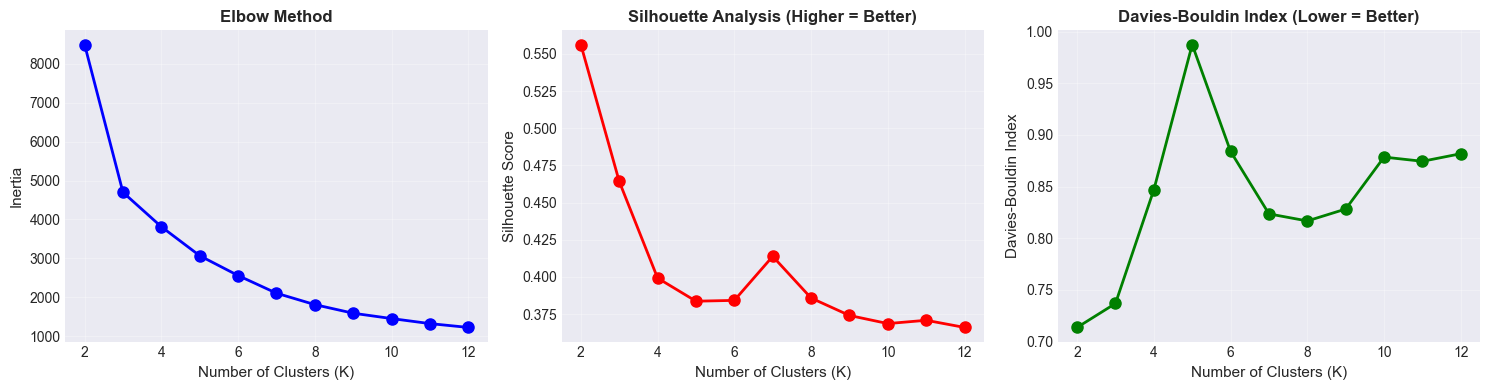

✅ Elbow analysis saved to: outputs/ml_results/elbow_analysis.png


In [28]:
# Create elbow plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: Inertia (Elbow Method)
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (K)', fontsize=11)
axes[0].set_ylabel('Inertia', fontsize=11)
axes[0].set_title('Elbow Method', fontweight='bold')
axes[0].grid(alpha=0.3)

# Plot 2: Silhouette Score
axes[1].plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (K)', fontsize=11)
axes[1].set_ylabel('Silhouette Score', fontsize=11)
axes[1].set_title('Silhouette Analysis (Higher = Better)', fontweight='bold')
axes[1].grid(alpha=0.3)

# Plot 3: Davies-Bouldin Index
axes[2].plot(K_range, db_scores, 'go-', linewidth=2, markersize=8)
axes[2].set_xlabel('Number of Clusters (K)', fontsize=11)
axes[2].set_ylabel('Davies-Bouldin Index', fontsize=11)
axes[2].set_title('Davies-Bouldin Index (Lower = Better)', fontweight='bold')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/ml_results/elbow_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Elbow analysis saved to: outputs/ml_results/elbow_analysis.png")

In [29]:
# Select optimal K
optimal_k = 8  # Based on elbow + business logic (matching RFM segments)

print(f"\n📊 Optimal K Selection:")
print(f"   • Silhouette suggests: K = {K_range[np.argmax(silhouette_scores)]}")
print(f"   • Davies-Bouldin suggests: K = {K_range[np.argmin(db_scores)]}")
print(f"   • Business logic: K = 8 (matches RFM segments)")
print(f"\n✅ Selected K = {optimal_k} (balances metrics + interpretability)")


📊 Optimal K Selection:
   • Silhouette suggests: K = 2
   • Davies-Bouldin suggests: K = 2
   • Business logic: K = 8 (matches RFM segments)

✅ Selected K = 8 (balances metrics + interpretability)


## 7. Final Model Training (K-Means with K=8)

Now we train the final K-Means model with the optimal K value. This model will:
- Assign each customer to one of 8 clusters
- Store cluster centers (mean RFM values per cluster)
- Be saved as .pkl file for deployment

The trained model can then predict which cluster any new customer belongs to based on their RFM values.

In [30]:
print("=" * 70)
print(f"FINAL MODEL TRAINING (K={optimal_k})")
print("=" * 70)

# Train final K-Means model
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10, max_iter=300)
rfm['ml_cluster'] = kmeans_final.fit_predict(X_scaled)

# Calculate evaluation metrics
sil_score = silhouette_score(X_scaled, rfm['ml_cluster'])
db_score = davies_bouldin_score(X_scaled, rfm['ml_cluster'])
ch_score = calinski_harabasz_score(X_scaled, rfm['ml_cluster'])

print(f"\n📊 Model Performance Metrics:")
print(f"   • Silhouette Score:        {sil_score:.4f}")
print(f"   • Davies-Bouldin Index:    {db_score:.4f}")
print(f"   • Calinski-Harabasz Score: {ch_score:.2f}")

print(f"\n📊 Cluster Distribution:")
print(rfm['ml_cluster'].value_counts().sort_index())

# Save the trained model
joblib.dump(kmeans_final, 'models/kmeans_model.pkl')
print(f"\n✅ K-Means model saved to: models/kmeans_model.pkl")

FINAL MODEL TRAINING (K=8)

📊 Model Performance Metrics:
   • Silhouette Score:        0.3858
   • Davies-Bouldin Index:    0.8167
   • Calinski-Harabasz Score: 7645.66

📊 Cluster Distribution:
ml_cluster
0     339
1    1136
2    1378
3     422
4    1028
5     631
6     653
7     413
Name: count, dtype: int64

✅ K-Means model saved to: models/kmeans_model.pkl


In [32]:
# Save model metadata
model_summary = {
    'model_type': 'K-Means Clustering',
    'n_clusters': optimal_k,
    'features': ml_features,
    'scaler': 'StandardScaler',
    'metrics': {
        'silhouette_score': float(sil_score),
        'davies_bouldin_index': float(db_score),
        'calinski_harabasz_score': float(ch_score)
    },
    'total_customers': len(rfm),
    'training_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
}

with open('models/model_summary.json', 'w') as f:
    json.dump(model_summary, f, indent=4)

print("✅ Model summary saved to: models/model_summary.json")

✅ Model summary saved to: models/model_summary.json


## 8. ML Cluster Profiling

Now we analyze each cluster to understand customer behavior patterns:
- How many customers are in each cluster?
- What are the average RFM values?
- Which clusters generate the most revenue?

This helps translate ML clusters into actionable business segments.

In [33]:
print("=" * 70)
print("ML CLUSTER PROFILING")
print("=" * 70)

# Calculate cluster statistics
cluster_profile = rfm.groupby('ml_cluster').agg({
    'customer_id': 'count',
    'recency': 'mean',
    'frequency': 'mean',
    'monetary': 'mean'
}).round(2)

cluster_profile.columns = ['Customers', 'Avg_Recency', 'Avg_Frequency', 'Total_Revenue']
cluster_profile['% of Total'] = (cluster_profile['Customers'] / len(rfm) * 100).round(1)

# Sort by revenue
cluster_profile = cluster_profile.sort_values('Total_Revenue', ascending=False)

print(f"\n📊 ML Cluster Profiles:")
print(cluster_profile)

# Save cluster profiles
cluster_profile.to_csv('outputs/ml_results/ml_cluster_profiles.csv')
print(f"\n✅ Cluster profiles saved to: outputs/ml_results/ml_cluster_profiles.csv")

ML CLUSTER PROFILING

📊 ML Cluster Profiles:
            Customers  Avg_Recency  Avg_Frequency  Total_Revenue  % of Total
ml_cluster                                                                  
3                 422       189.55          35.74       10303.55        7.00
0                 339       480.83          25.08        7003.51        5.60
7                 413        71.47          24.24        6515.33        6.90
6                 653       298.01          14.29        2485.56       10.90
2                1378        58.38           9.25        1437.29       23.00
1                1136       506.62           5.56         766.21       18.90
4                1028       270.19           4.03         483.19       17.10
5                 631       751.52           2.54         297.06       10.50

✅ Cluster profiles saved to: outputs/ml_results/ml_cluster_profiles.csv


## 9. 3D Cluster Visualization

Visualizing clusters in 3D RFM space helps us see:
- How well-separated the clusters are
- Whether there are any overlapping segments
- The spatial distribution of customers

Each point represents a customer, colored by their ML cluster assignment.

Creating 3D cluster visualization...


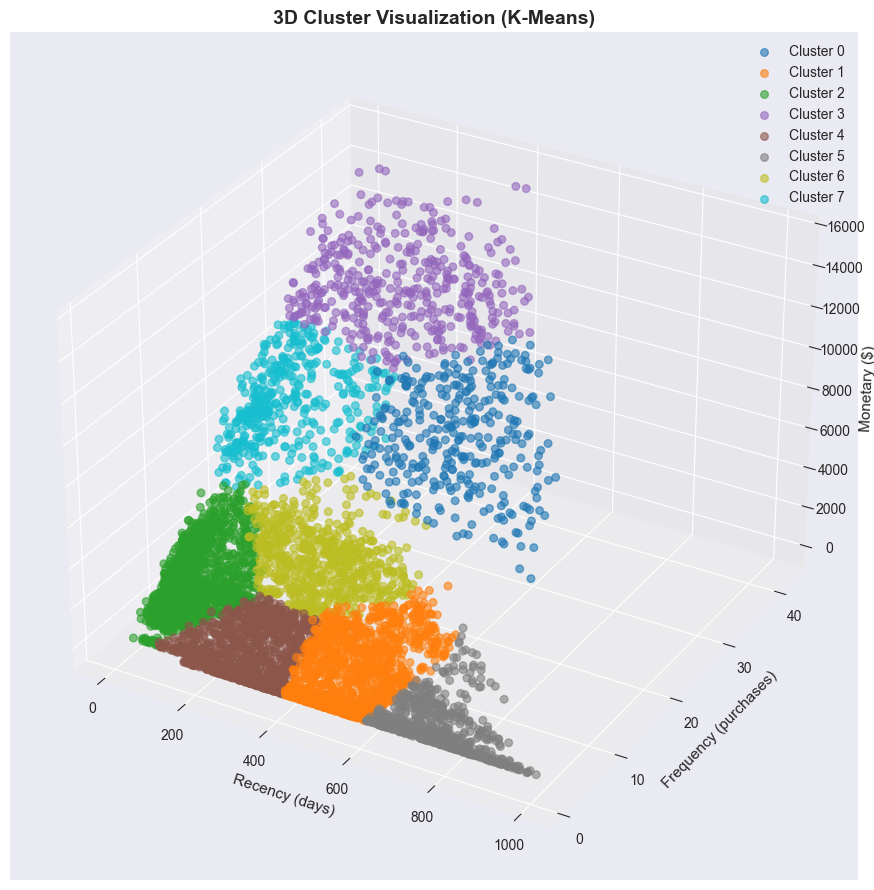

✅ 3D visualization saved to: outputs/ml_results/3d_cluster_viz.png


In [35]:
from mpl_toolkits.mplot3d import Axes3D

print("Creating 3D cluster visualization...")

fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

colors = plt.cm.tab10(np.linspace(0, 1, optimal_k))

for i in range(optimal_k):
    cluster_data = rfm[rfm['ml_cluster']==i]
    ax.scatter(cluster_data['recency'], 
              cluster_data['frequency'], 
              cluster_data['monetary'],
              c=[colors[i]], 
              label=f'Cluster {i}',
              alpha=0.6,
              s=30)

ax.set_xlabel('Recency (days)', fontsize=11)
ax.set_ylabel('Frequency (purchases)', fontsize=11)
ax.set_zlabel('Monetary ($)', fontsize=11)
ax.set_title('3D Cluster Visualization (K-Means)', fontsize=14, fontweight='bold')
ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig('outputs/ml_results/3d_cluster_viz.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ 3D visualization saved to: outputs/ml_results/3d_cluster_viz.png")

## 10. Rule-Based RFM Segmentation (For Comparison)

To evaluate our ML approach, we'll also create traditional rule-based RFM segments using:
1. **R/F/M Scores:** Divide each metric into quintiles (1-5)
2. **Business Rules:** Apply if-elif logic to assign segment names

This allows us to compare ML-discovered patterns vs. human-defined rules.

In [36]:
print("=" * 70)
print("RULE-BASED RFM SEGMENTATION")
print("=" * 70)

# Calculate RFM scores (quintiles)
rfm['r_score'] = pd.qcut(rfm['recency'], q=5, labels=[5,4,3,2,1], duplicates='drop')
rfm['f_score'] = pd.qcut(rfm['frequency'].rank(method='first'), q=5, labels=[1,2,3,4,5], duplicates='drop')
rfm['m_score'] = pd.qcut(rfm['monetary'].rank(method='first'), q=5, labels=[1,2,3,4,5], duplicates='drop')

print("✅ RFM scores calculated (1-5 scale)")
print(f"\nSample RFM scores:")
print(rfm[['customer_id', 'recency', 'r_score', 'frequency', 'f_score', 'monetary', 'm_score']].head(10))

RULE-BASED RFM SEGMENTATION
✅ RFM scores calculated (1-5 scale)

Sample RFM scores:
  customer_id  recency r_score  frequency f_score  monetary m_score
0  CUST_00001       52       5          5       2    577.02       2
1  CUST_00002      915       1          1       1     76.42       1
2  CUST_00003      493       2          1       1    202.39       1
3  CUST_00004      312       3          2       1     37.12       1
4  CUST_00005       10       5         36       5  11341.89       5
5  CUST_00006      135       4          5       2    403.84       2
6  CUST_00007      655       1          2       1    325.35       2
7  CUST_00008      228       3          9       3   1504.88       3
8  CUST_00009      472       2          1       1     11.33       1
9  CUST_00010       70       4          7       2    677.52       2


In [37]:
# Define segmentation logic
def segment_customers(row):
    r, f, m = int(row['r_score']), int(row['f_score']), int(row['m_score'])
    
    if   r >= 4 and f >= 4 and m >= 4: return 'Champions'
    elif r <= 2 and m >= 4:            return 'Cannot Lose Them'
    elif f >= 4:                       return 'Loyal Customers'
    elif r >= 4 and f >= 2:            return 'Potential Loyalists'
    elif r >= 4 and f == 1:            return 'New Customers'
    elif f >= 3 and r <= 2:            return 'At Risk'
    elif r <= 2:                       return 'Hibernating'
    else:                              return 'Need Attention'

# Apply segmentation
rfm['rfm_segment'] = rfm.apply(segment_customers, axis=1)

print("\n✅ RFM segments assigned")
print(f"\n📊 RFM Segment Distribution:")
print(rfm['rfm_segment'].value_counts().sort_values(ascending=False))


✅ RFM segments assigned

📊 RFM Segment Distribution:
rfm_segment
Hibernating            1385
Champions              1136
Potential Loyalists    1035
Loyal Customers         692
Need Attention          678
Cannot Lose Them        641
At Risk                 296
New Customers           137
Name: count, dtype: int64


## 11. ML vs RFM Comparison

**Key Question:** How do ML-discovered clusters compare to rule-based RFM segments?

We'll create:
1. **Cross-tabulation matrix:** Shows overlap between ML clusters and RFM segments
2. **Heatmap visualization:** Visual representation of the overlap

**What to look for:**
- High values on diagonal = strong agreement
- Scattered values = ML found patterns RFM rules missed

In [39]:
print("=" * 70)
print("ML vs RFM COMPARISON")
print("=" * 70)

# Create cross-tabulation
comparison = pd.crosstab(rfm['rfm_segment'], rfm['ml_cluster'], margins=True)

print("\n📊 ML Clusters vs RFM Segments:")
print(comparison)

# Save comparison
comparison.to_csv('outputs/ml_results/ml_vs_rfm_comparison.csv')
print("\n✅ Comparison saved to: outputs/ml_results/ml_vs_rfm_comparison.csv")

ML vs RFM COMPARISON

📊 ML Clusters vs RFM Segments:
ml_cluster             0     1     2    3     4    5    6    7   All
rfm_segment                                                         
At Risk                0   261     0    0    10   24    1    0   296
Cannot Lose Them     278   133     0   60     0    9  161    0   641
Champions              0     0   379  243     0    0  146  368  1136
Hibernating            0   685     0    0   105  595    0    0  1385
Loyal Customers       61    57    97  119     1    3  309   45   692
Need Attention         0     0     0    0   645    0   33    0   678
New Customers          0     0    20    0   117    0    0    0   137
Potential Loyalists    0     0   882    0   150    0    3    0  1035
All                  339  1136  1378  422  1028  631  653  413  6000

✅ Comparison saved to: outputs/ml_results/ml_vs_rfm_comparison.csv


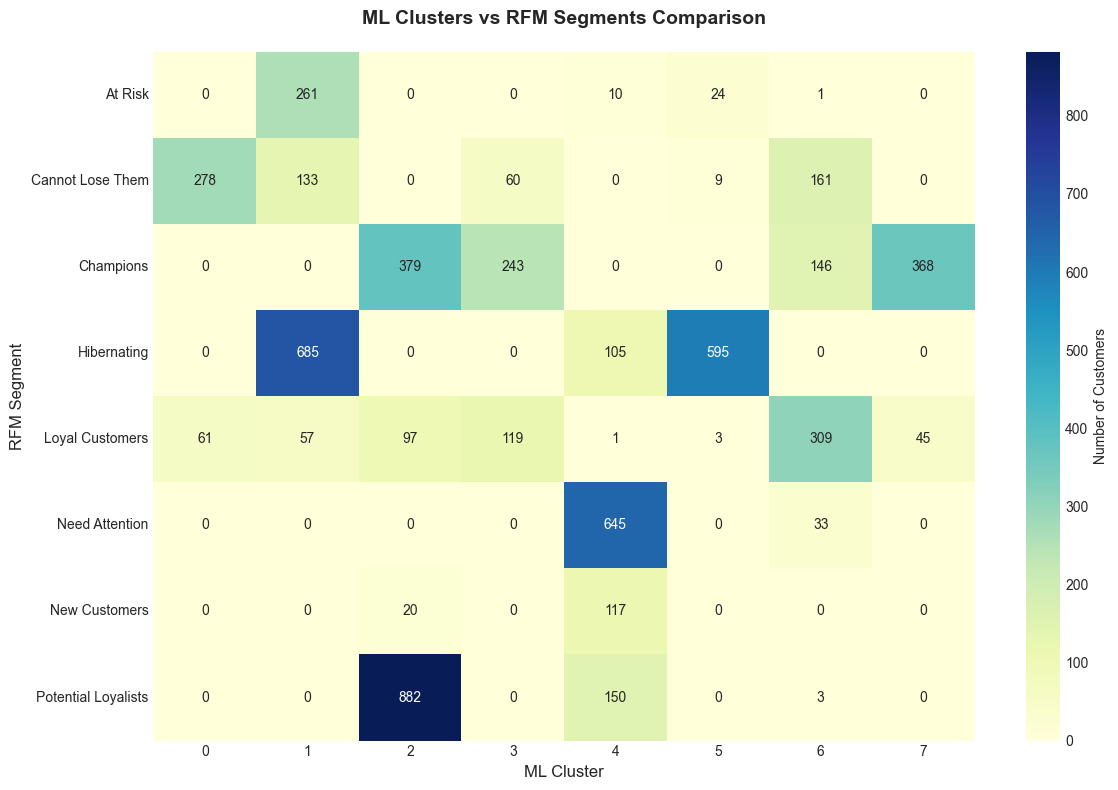

✅ Comparison heatmap saved to: outputs/ml_results/ml_vs_rfm_heatmap.png


In [40]:
# Create heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(comparison.iloc[:-1, :-1], annot=True, fmt='d', cmap='YlGnBu', 
            cbar_kws={'label': 'Number of Customers'})
plt.title('ML Clusters vs RFM Segments Comparison', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('ML Cluster', fontsize=12)
plt.ylabel('RFM Segment', fontsize=12)
plt.tight_layout()
plt.savefig('outputs/ml_results/ml_vs_rfm_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Comparison heatmap saved to: outputs/ml_results/ml_vs_rfm_heatmap.png")

In [41]:
print("=" * 70)
print("SAVING FINAL DATASET")
print("=" * 70)

# Select final columns
rfm_final = rfm[['customer_id', 'recency', 'frequency', 'monetary', 
                 'ml_cluster', 'rfm_segment', 'r_score', 'f_score', 'm_score']]

# Save enriched dataset
rfm_final.to_csv('../data/customer_rfm_with_ml.csv', index=False)

print(f"✅ Final dataset saved to: data/customer_rfm_with_ml.csv")
print(f"   Total customers: {len(rfm_final):,}")
print(f"   Columns: {list(rfm_final.columns)}")

SAVING FINAL DATASET
✅ Final dataset saved to: data/customer_rfm_with_ml.csv
   Total customers: 6,000
   Columns: ['customer_id', 'recency', 'frequency', 'monetary', 'ml_cluster', 'rfm_segment', 'r_score', 'f_score', 'm_score']
